# Paradox of Enrichment

# Load Packages

In [2]:
push!(LOAD_PATH, pwd()) # put current directory on path
using Revise
using UnPack
#include("ModelHelperFuns.jl")  # load the file
#using .ModelHelperFuns         # bring the module into scope
using CooperativeHuntingPkg
using Plots
default(
    guidefontsize=14,   # controls xlabel, ylabel, title font size
    tickfontsize=12,    # controls axis number labels
    legendfontsize=14,  # controls legend font
    linewidth=3,        # controls default line thickness
    grid = false,        # turns off grid in background
    fontfamily="Computer Modern" # font family that matches latex
)
using BifurcationKit, DifferentialEquations
# pgfplotsx()  # Set PGFPlotsX as the backend # this seems to not work on my computer, or on vscode.
using Measures # helps for adjusting location of axis labels
bif_fig_path = "/Users/taliaborofsky/Documents/Postdoc/Collaborations/CH_GroupFormation/CH_manuscript/FIgures/BifurcationDiagrams/"
using LaTeXStrings


# Basic Parameters

In [3]:
params_base = Dict(
    :α1_of_1 => 0.05,
    :α2_of_1 => 0.95,
    :s1 => 2.0,
    :s2 => 2.0,
    :H1a => 0.0,
    :H2a => 0.0,
    :H2b => 0.0,
    :A1 => 0.6,
    :A2 => 0.5,
    :η2 => 0.6,
    :β2 => 1.0,
    :α2_fun_type => "constant",
    :x_max => 10,
    :Tg => .01,
    :d => 100.0,
    :scale => 5.0
)
u0 = [0.1,0.1, fill(0.1,params_base[:x_max])...]


12-element Vector{Float64}:
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1

## Population + Group Dynamics

### Manual Scan

#### Type II, Vary A2 (scale 5 A1 low at 0.6)

did base continuations
hi

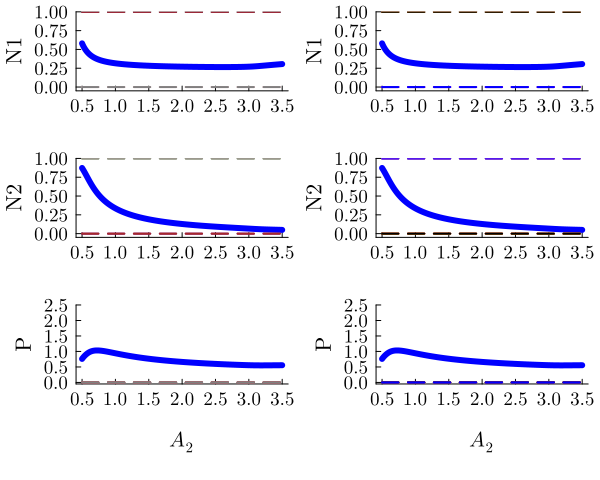

In [5]:
params = deepcopy(params_base)
params[:H1a] = params[:H2a] = 0.0
params[:H2b] = 1.0
params[:scale] = 5.0
params[:A1] = 0.6
p_nt = NamedTuple(scale_parameters(params))

br_list, extra_branches = diagram_2_recursion(
    p_nt, ; lens = (@optic _.A2), paramkey = :A2,
    p_min = 0.5, p_max = 3.5, 
    systemfunction = fullsystem_scaled);
#plot_comparison_branches(br_list, extra_branches; ymax = 3.5)
plot_comparison_branches_filtered(
    br_list, [br_list...,extra_branches...], :A2;
     ymax = 2.5, x_max = 5)

#### Type II, Vary A2 (scale 5 A1 high at 1.0)

[0.2331041742082235, 0.8949101737592415, 0.11744692495339291, 0.06489380047509569, 0.10344861510918114, 0.006754104793592224, 3.601103539561476e-5, 8.002446131706382e-8, 1.4682594070228974e-10, 2.464687496830634e-13, 3.850026093220233e-16, 5.62860837580588e-19][1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.6393078469825043, 0.0, 0.0042951355080294, 0.0028879534082415915, 0.003902250717141337, 0.00542731826126445, 0.00713107714554143, 0.0087949157008534, 0.010197330791848978, 0.011099224202494913, 0.011224999764811325, 0.010101650152213334][0.0, 0.9999999999999467, -5.768839246615161e-9, 2.6085791873048875e-8, -6.989993492205568e-8, 1.229761342444703e-7, -1.4846114329683336e-7, 1.245810935436039e-7, -7.178033370860253e-8, 2.719379649056383e-8, -6.124057074948218e-9, 6.24018294137066e-10][0.9998489945252559, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.0, 0.9995805607141938, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]did base continuations
[0.0, 1.0, -8.

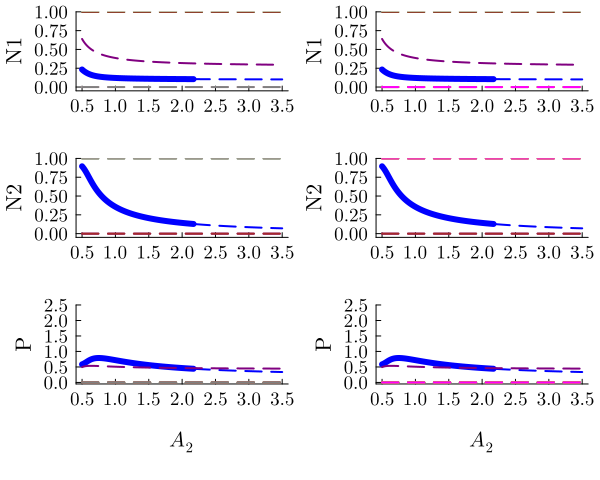

In [ ]:
params = deepcopy(params_base)
params[:H1a] = params[:H2a] = 0.0
params[:H2b] = 1.0
params[:scale] = 5.0
params[:A1] = 1.5
p_nt = NamedTuple(scale_parameters(params))

br_list, extra_branches = diagram_2_recursion(
    p_nt, ; lens = (@optic _.A2), paramkey = :A2,
    p_min = 0.5, p_max = 3.5, 
    systemfunction = fullsystem_scaled);
#plot_comparison_branches(br_list, extra_branches; ymax = 3.5)
plot_comparison_branches_filtered(
    br_list, [br_list...,extra_branches...], :A2;
     ymax = 2.5, x_max = 5)

#### Type II, Vary A2 (scale 2 A1 low at 0.6)

did base continuations
hi

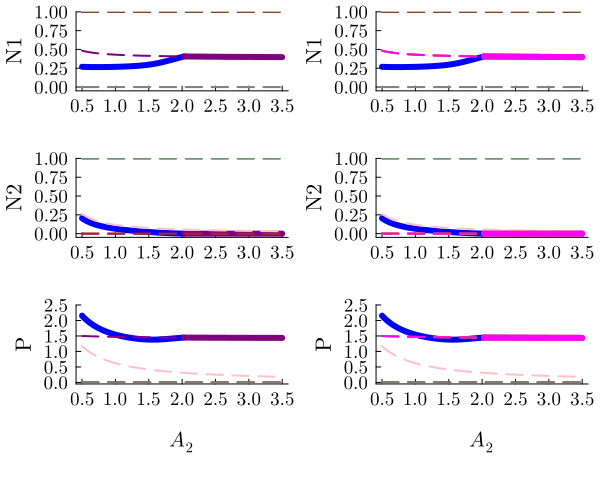

In [22]:
params = deepcopy(params_base)
params[:H1a] = params[:H2a] = 0.0
params[:H2b] = 1.0
params[:scale] = 2.0
params[:A1] = 0.6
p_nt = NamedTuple(scale_parameters(params))

br_list, extra_branches = diagram_2_recursion(
    p_nt, ; lens = (@optic _.A2), paramkey = :A2,
    p_min = 0.5, p_max = 3.5, 
    systemfunction = fullsystem_scaled);
#plot_comparison_branches(br_list, extra_branches; ymax = 3.5)
plot_comparison_branches_filtered(
    br_list, [br_list...,extra_branches...], :A2;
     ymax = 2.5, x_max = 5)

In [28]:
bif_N2 = plot_nice_bif(br_list, :N2, :A2)
savefig(bif_N2, bif_fig_path*"bif_N2extinct_scalelow.pdf")

"/Users/taliaborofsky/Documents/Postdoc/Collaborations/CH_GroupFormation/CH_manuscript/FIgures/BifurcationDiagrams/bif_N2extinct_scalelow.pdf"

#### Type II, Vary A2 (scale 2 A1 high at 1.0)

[0.09635271310602389, 0.2396460282806972, 0.913305246471133, 0.22117961993458776, 0.07277596415528192, 0.0027021660612861357, 2.0609940219696392e-5, 5.5046814816791095e-8, 7.417143425642452e-11, 6.382068647597325e-14, 4.0490473917187125e-17, 2.0642249219052804e-20][1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.4470604030681429, 0.0, 0.014337594606467673, 0.006226625579438368, 0.0056606888441058135, 0.006193601703087555, 0.009262626335958268, 0.02079891683894576, 0.04751695896908263, 0.06410094348283496, 0.03766334201544206, 0.009173912867205244][0.0, 0.2642843959252067, 1.1576798533132275, 0.004466697797704581, 5.109706032403005e-6, 2.5436681732538846e-7, -3.026683353091379e-7, 2.528985573940073e-7, -1.449444073199522e-7, 5.454696041574495e-8, -1.2176386482481292e-8, 1.2253194533710525e-9][0.9990934107313862, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.0, 0.9995805607141938, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]did base continuations
[0.15469596

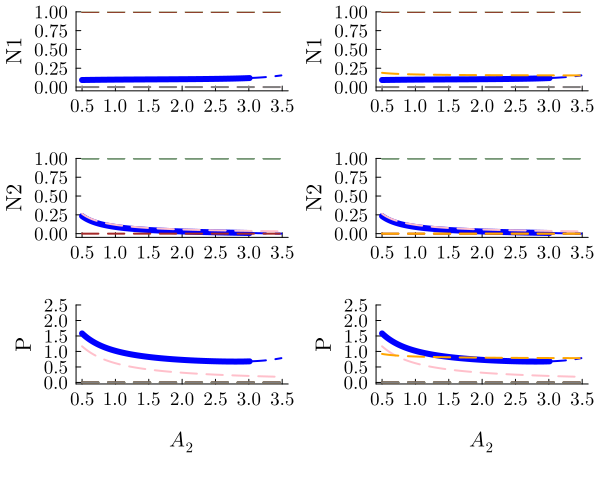

In [ ]:
params = deepcopy(params_base)
params[:H1a] = params[:H2a] = 0.0
params[:H2b] = 1.0
params[:scale] = 2.0
params[:A1] = 1.5
p_nt = NamedTuple(scale_parameters(params))

br_list, extra_branches = diagram_2_recursion(
    p_nt, ; lens = (@optic _.A2), paramkey = :A2,
    p_min = 0.5, p_max = 3.5, 
    systemfunction = fullsystem_scaled);
#plot_comparison_branches(br_list, extra_branches; ymax = 3.5)
plot_comparison_branches_filtered(
    br_list, [br_list...,extra_branches...], :A2;
     ymax = 2.5, x_max = 5)

### 2D Scan

In [3]:
# I want to generate a plot with A2 on the x-axis, beta1/beta2 on the y-axis, and for each combination, we find the minimum A1 for which there is no stable equilibrium 
# (which means there is no stable equilibrium in the coexistence, :N1extinct, or :N2extinct branches)


# For a given set of continuation branches, find the largest A1 value
# at which at least one of the target branches is still stable.
# Just above this value, there is no stable equilibrium in those branches.
function stable_A1_cutoff(br_list, x_max; branch_names = (:coexist, :N1_extinct, :N2_extinct))
    stable_params = Float64[]

    for branch_name in branch_names
        branch = getproperty(br_list, branch_name)
        out = extract_branch_matrix(branch, x_max)

        if !isempty(out.param)
            append!(stable_params, out.param[out.stable .== 1.0]) # out.stable is 1.0 if stable. needs to be changed to bool
        end
    end

    stable_params = filter(isfinite, stable_params)
    isempty(stable_params) && return -Inf
    return maximum(stable_params)
end


stable_A1_cutoff (generic function with 1 method)

scale_val = 2.0
A2_val = 0.5
stable_limit = 4.0
scale_val = 2.0
A2_val = 0.75
stable_limit = 4.0
scale_val = 2.2777777777777777
A2_val = 0.5
stable_limit = 4.0
scale_val = 2.2777777777777777
A2_val = 0.75
stable_limit = 4.0
scale_val = 2.2777777777777777
A2_val = 1.0
stable_limit = 4.0
scale_val = 2.5555555555555554
A2_val = 0.5
stable_limit = 4.0
scale_val = 2.5555555555555554
A2_val = 0.75
stable_limit = 4.0
scale_val = 2.5555555555555554
A2_val = 1.0
stable_limit = 4.0
scale_val = 2.5555555555555554
A2_val = 1.25
stable_limit = 4.0
scale_val = 2.8333333333333335
A2_val = 0.5
stable_limit = 4.0
scale_val = 2.8333333333333335
A2_val = 0.75
stable_limit = 4.0
scale_val = 2.8333333333333335
A2_val = 1.0
stable_limit = 4.0
scale_val = 2.8333333333333335
A2_val = 1.25
stable_limit = 4.0
scale_val = 2.8333333333333335
A2_val = 1.5
stable_limit = 4.0
scale_val = 3.111111111111111
A2_val = 0.5
stable_limit = 4.0
scale_val = 3.111111111111111
A2_val = 0.75
stable_limit = 4.0
scale_val = 3.111

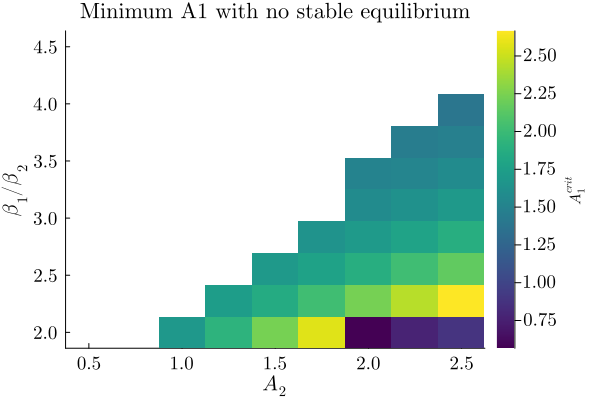

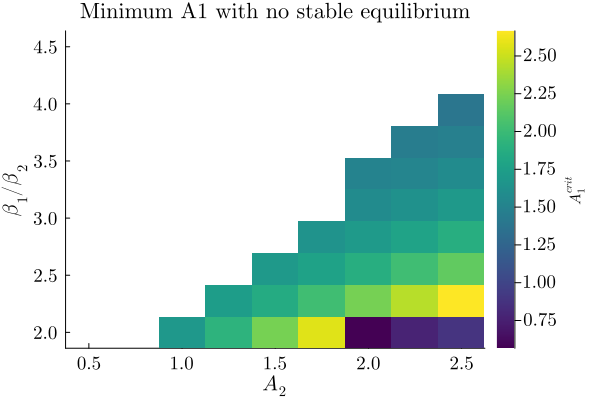

In [ ]:

# Scan over A2 and beta1/beta2 (stored here as `scale`), and for each pair
# continue in A1 to estimate the smallest A1 for which no stable equilibrium remains
# in the coexistence, N1_extinct, or N2_extinct branches.
function minimum_A1_without_stable_equilibrium(
    params_base;
    A2_vec = collect(0.5:0.5:2.5),
    scale_vec = collect(range(2.0,5.0,length=3)),#collect(2.0:0.5:5.0),
    A1_min = 0.5,
    A1_max = 3.0,
    branch_names = (:coexist, :N1_extinct, :N2_extinct)
)
    A1_threshold_mat = fill(NaN, length(scale_vec), length(A2_vec))

    for (i, scale_val) in enumerate(scale_vec)
        for (j, A2_val) in enumerate(A2_vec)
            # Start from the base parameter set and overwrite the parameters
            # that define the current point in the heatmap.
            params = deepcopy(params_base)
            params[:H1a] = 0.0
            params[:H2a] = 0.0
            params[:H2b] = 1.0
            params[:scale] = scale_val
            params[:A2] = A2_val
            params[:A1] = 0.6

            p_nt = NamedTuple(scale_parameters(params))

            try
                # Continue the system in A1 while holding A2 and beta1/beta2 fixed.
                br_scan = do_base_continuations(
                    p_nt,
                    p_nt.x_max;
                    lens = (@optic _.A1),
                    p_min = A1_min,
                    p_max = A1_max,
                    systemfunction = fullsystem_scaled
                )

                # Find the last A1 value with any stable equilibrium in the target branches.
                stable_limit = stable_A1_cutoff(
                    br_scan,
                    p_nt.x_max;
                    branch_names = branch_names
                )
                

                # If there are no stable points at all, then the threshold is already at A1_min.
                if stable_limit == -Inf
                    A1_threshold_mat[i, j] = A1_min

                # Otherwise record the last stable A1, provided the loss of stability
                # happens before the upper end of the continuation interval.
                elseif stable_limit < A1_max - 1e-3
                    A1_threshold_mat[i, j] = stable_limit
                else
                    @show scale_val
                    @show A2_val
                    @show stable_limit
                end
            catch err
                # Leave failed parameter combinations as NaN so they appear blank in the heatmap.
                @warn "Continuation failed for parameter combination" scale_val A2_val err
            end
        end
    end

    return A1_threshold_mat
end

# Define the heatmap grid.
A2_vec = collect(0.5:0.25:2.5)
scale_vec = collect(range(2.0,4.5,length=10))
A1_min = 0.5
A1_max = 4.0

# Compute the threshold matrix.
A1_threshold_mat = minimum_A1_without_stable_equilibrium(
    params_base;
    A2_vec = A2_vec,
    scale_vec = scale_vec,
    A1_min = A1_min,
    A1_max = A1_max
)

# Plot the threshold as a heatmap:
# x-axis = A2
# y-axis = beta1/beta2
# color = minimum A1 above which no stable equilibrium remains
# in coexistence, N1_extinct, or N2_extinct.
plt_A1_threshold = heatmap(
    A2_vec,
    scale_vec,
    A1_threshold_mat,
    xlabel = L"A_2",
    ylabel = L"\beta_1 / \beta_2",
    title = "Minimum A1 with no stable equilibrium",
    color = :viridis,
    right_margin = 8mm,
    colorbar_title = "\n"*L"A_1^{crit}"
)

display(plt_A1_threshold)
plt_A1_threshold

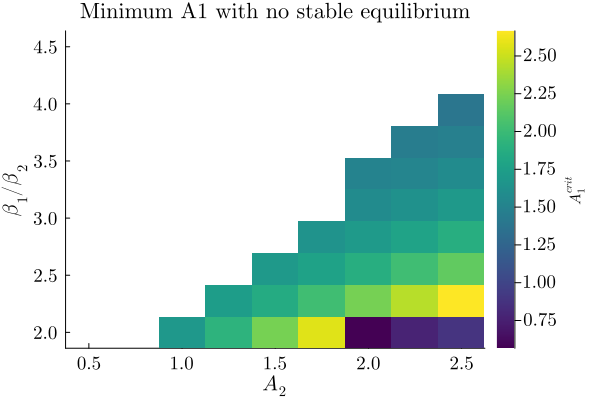

In [ ]:
plt_A1_threshold = heatmap(
    A2_vec,
    scale_vec,
    A1_threshold_mat,
    xlabel = L"A_2",
    ylabel = L"\beta_1 / \beta_2",
    title = "Minimum A1 with no stable equilibrium",
    color = :viridis,
    right_margin = 8mm,
    colorbar_title = "\n"*L"A_1^{crit}"
)
savefig(plt_A1_threshold, bif_fig_path*"min_A1_nostability.pdf")
plt_A1_threshold


In [ ]:
plt_A1_threshold
plot!(title="")
plot!(ylab = L"Benefit Ratio, $\beta_1/\beta_2$")
plot!(xlab = L"Attack Rate on Small Prey, $A_2$")
savefig(plt_A1_threshold, bif_fig_path*"min_A1_nostability.pdf")


"/Users/taliaborofsky/Documents/Postdoc/Collaborations/CH_GroupFormation/CH_manuscript/FIgures/BifurcationDiagrams/min_A1_nostability.pdf"

For the uncolored region: couldn't find an A1 in the range tested for which no stable equilibrium


For the colored region: For each A2 value, generally as scale increases, the minimum A1 value for which you have a stable equilibrium decreases...so can more easily get enrichment.
For each scale value escept 2.0, increasing A2 increases the cutoff A1 value

So actually increasing scale is not increasing stability


### Investigating what's going on bottom row

#### The yellow spot

did base continuations
hi

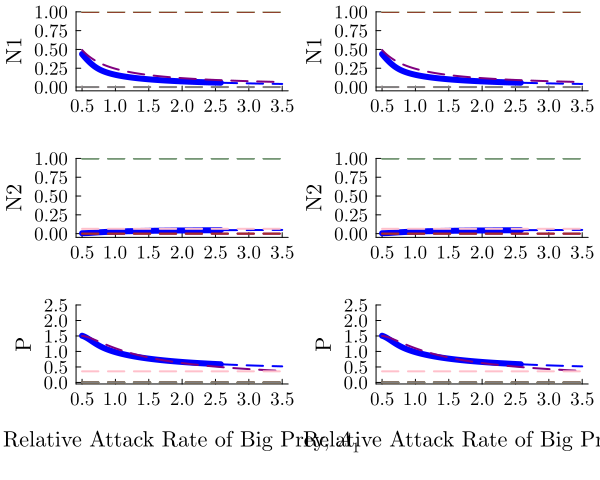

In [23]:
params = deepcopy(params_base)
params[:H1a] = params[:H2a] = 0.0
params[:H2b] = 1.0
params[:scale] = 2.0
params[:A2] = 1.75
p_nt = NamedTuple(scale_parameters(params))

br_list, extra_branches = diagram_2_recursion(
    p_nt, ; lens = (@optic _.A1), paramkey = :A1,
    p_min = 0.5, p_max = 3.5, 
    systemfunction = fullsystem_scaled);
#plot_comparison_branches(br_list, extra_branches; ymax = 3.5)
plot_comparison_branches_filtered(
    br_list, [br_list...,extra_branches...], :A1;
     ymax = 2.5, x_max = 5)

#### The dark blue grids

did base continuations
hi

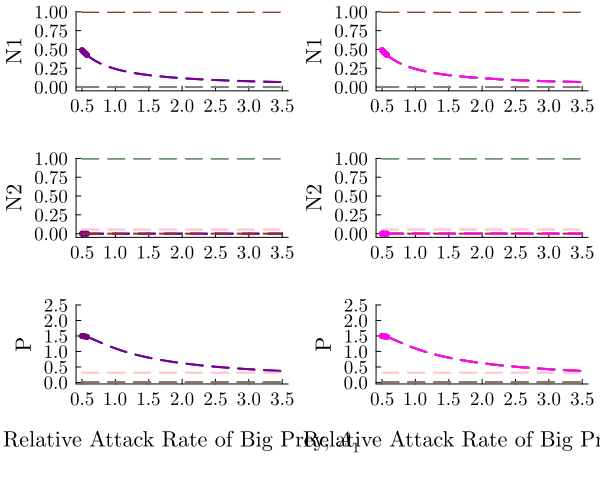

In [21]:
params = deepcopy(params_base)
params[:H1a] = params[:H2a] = 0.0
params[:H2b] = 1.0
params[:scale] = 2.0
params[:A2] = 2.0
p_nt = NamedTuple(scale_parameters(params))

br_list, extra_branches = diagram_2_recursion(
    p_nt, ; lens = (@optic _.A1), paramkey = :A1,
    p_min = 0.5, p_max = 3.5, 
    systemfunction = fullsystem_scaled);
#plot_comparison_branches(br_list, extra_branches; ymax = 3.5)
plot_comparison_branches_filtered(
    br_list, [br_list...,extra_branches...], :A1;
     ymax = 2.5, x_max = 5)

did base continuations
hi

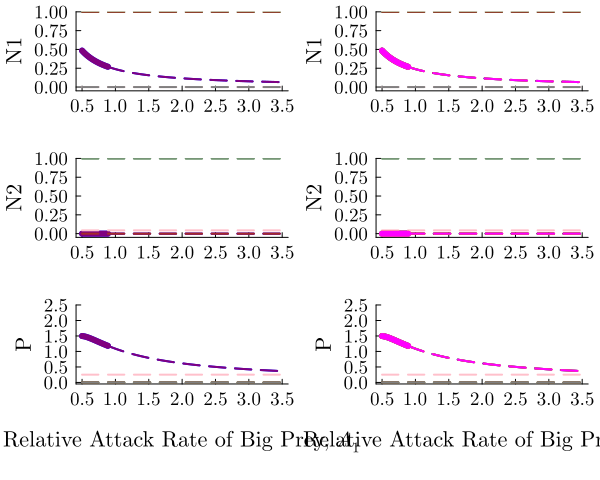

In [25]:
params = deepcopy(params_base)
params[:H1a] = params[:H2a] = 0.0
params[:H2b] = 1.0
params[:scale] = 2.0
params[:A2] = 2.5
p_nt = NamedTuple(scale_parameters(params))

br_list, extra_branches = diagram_2_recursion(
    p_nt, ; lens = (@optic _.A1), paramkey = :A1,
    p_min = 0.5, p_max = 3.5, 
    systemfunction = fullsystem_scaled);
#plot_comparison_branches(br_list, extra_branches; ymax = 3.5)
plot_comparison_branches_filtered(
    br_list, [br_list...,extra_branches...], :A1;
     ymax = 2.5, x_max = 5)

N2 is extinct for these cells... not getting coexistence at all for any value of A1 tested. That's why the trend is different.

### Now simulate over time

In [11]:
u0 = [0.1,0.1, fill(0.1,params_base[:x_max])...]

params = deepcopy(params_base)
params[:H1a] = params[:H2a] = 0.0
params[:H2b] = 1.0
params[:scale] = 2.5
params[:A1] = 2.2
params[:A2] = 2.0
p_nt = NamedTuple(scale_parameters(params))

u0_new = iterate_to_last_pt_scaled(u0, p_nt; tf = 1500) # 1500 burner steps

tspan = (0.0, 100)
prob = ODEProblem(fullsystem_scaled!, u0_new, tspan, p_nt)
sol = solve(prob)



retcode: Success
Interpolation: 3rd order Hermite
t: 360-element Vector{Float64}:
   0.0
   0.021690158661623337
   0.029367666807545486
   0.03648895322507918
   0.041927225484129194
   0.04716494884891552
   0.052067023140081325
   0.05658581970629874
   0.06519836379055464
   0.07513094540981653
   ⋮
  96.84888451448107
  97.33066447797098
  97.86721014754377
  98.33104838833172
  98.79236803342927
  99.19483172797335
  99.60822588762363
  99.97693118701375
 100.0
u: 360-element Vector{Vector{Float64}}:
 [0.039917628165974633, 0.02266874243628935, 0.15276300644610266, 0.04769396549049201, 0.03911301745325203, 0.004473019167845085, 0.00012198183818361596, 1.230632783424492e-6, 6.020813799868318e-9, 1.7026666692334165e-11, 3.138097622657774e-14, 4.1069582797666977e-17]
 [0.03998304082718475, 0.02273624924176352, 0.15258231543491974, 0.0476016548851885, 0.03900803554749516, 0.004458345710578266, 0.00011688432123489955, -4.369260766049204e-7, 5.932937100839272e-9, 1.0174857605352875e-10

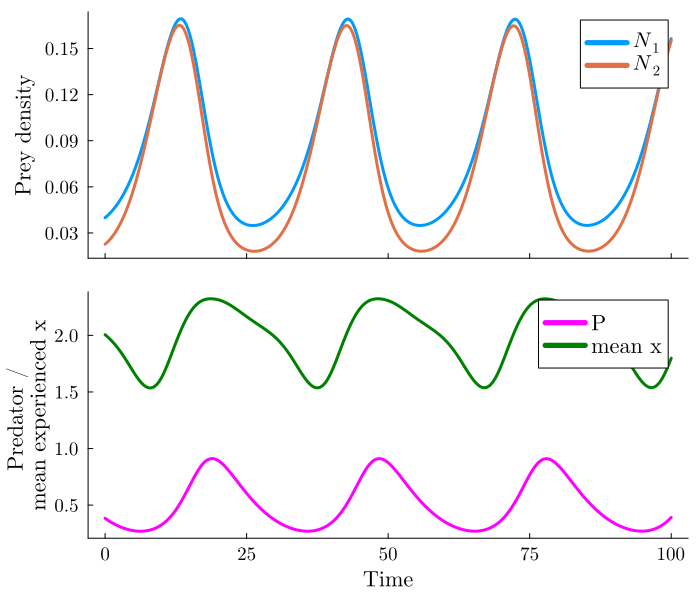

In [18]:
u = hcat(sol.u...)
N1 = u[1, :]
N2 = u[2, :]
gmat = u[3:end, :]

P = get_p(gmat, p_nt.x_max)[:]
meanx = get_meanx(gmat, p_nt.x_max)

plt1 = plot(
    sol.t, N1;
    label = L"N_1",
    ylabel = "Prey density",
    legend = :topright,
    xformatter = _ -> ""
)

plot!(plt1, sol.t, N2; label = L"N_2")

plt2 = plot(
    sol.t, P;
    label = "P",
    color = :magenta,
    xlabel = "Time",
    ylabel = "Predator / \nmean experienced x",
    legend = :topright
)

plot!(plt2, sol.t, meanx'; label = "mean x", color = :green)

plt = plot(
    plt1, plt2;
    layout = (2, 1),
    link = :x,
    size = (700, 600)
)

savefig(plt, bif_fig_path*"cycling_populations.pdf")
display(plt)

In [19]:
function heatmap_probx_time(sol, p_nt)
    #=
    uses a heatmap to plot Prob(x) over time
    uses the function fun_W to get W and thus find the highest x for which W(x) >= W(1) (called x^*)
        and the x that maximizes W (called x_0)
    =#
    t = sol.t
    u = hcat(sol.u...)
    N1, N2, gmat = u[1,:], u[2,:], u[3:end,:]
    P = get_p(gmat, p_nt.x_max)[:]
    meanx = get_meanx(gmat, p_nt.x_max)

    prob = get_prob_in_x(transpose(gmat), P, p_nt.x_max)

    hm = heatmap(
        sol.t,     # x = rows
        1:size(prob,2),     # y = columns
        prob',              # transpose so rows map to x
        c = cgrad(:grays, rev=true),    # high values → dark
        #colorrev=false,      # darker = higher
        xlabel="\n"*"time",
        ylabel=L"Group size, $x$",
        title="Probability heatmap",
        ylims = [1, params_base[:x_max]]
    )
    
    Wvecs = [fun_W(i,N1,N2,p_nt) for i in 1:10]
    Wmat = hcat(Wvecs...)
    
    # mangle and clark prediction
    x_mc_vec = [
        let idx = findfirst(Wmat[i, 2:end] .< Wmat[i, 1])
            isnothing(idx) ? p_nt[:x_max] : idx + 1
        end
        for i in axes(Wmat, 1)
    ]
    x_opt_vec = argmax.(eachrow(Wmat))

    
    plot!(sol.t, x_mc_vec, label = "Clark & Mangel", color = :limegreen)
    plot!(sol.t, x_opt_vec, label = "Optimal", color = :purple)
    plot!(sol.t, meanx', label = "Mean Experienced", color = :yellow)
    return hm
end

heatmap_probx_time (generic function with 1 method)

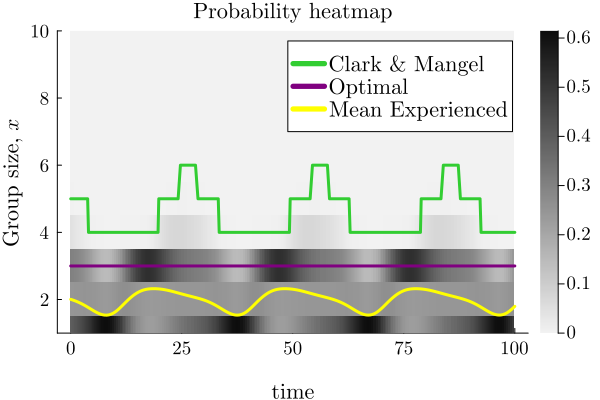

In [21]:
hm = heatmap_probx_time(sol, p_nt)
savefig(hm, bif_fig_path*"cycling_groups.pdf")
hm

In [ ]:
gmat = hcat([u[3:end] for u in sol.u]...)
p = get_p(gmat, p_nt.x_max)
meanx = get_meanx(gmat, p_nt.x_max)
probmat = get_prob_in_x(transpose(gmat),p[:],p_nt.x_max)


did base continuations
hi

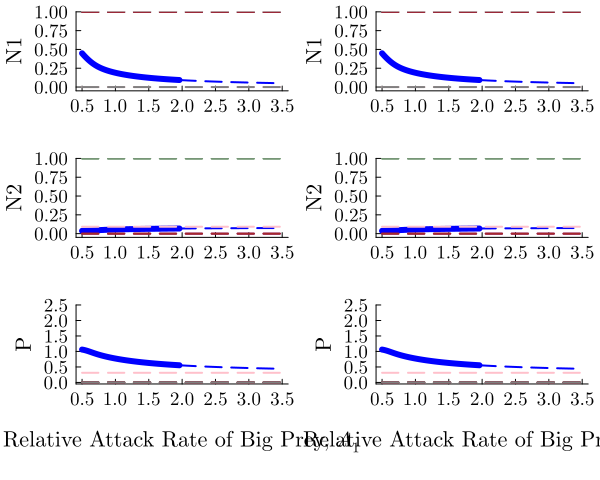

In [35]:
params = deepcopy(params_base)
params[:H1a] = params[:H2a] = 0.0
params[:H2b] = 1.0
params[:scale] = 2.5
params[:A1] = 2.2
params[:A2] = 2.0
p_nt = NamedTuple(scale_parameters(params))

br_list, extra_branches = diagram_2_recursion(
    p_nt, ; lens = (@optic _.A1), paramkey = :A1,
    p_min = 0.5, p_max = 3.5, 
    systemfunction = fullsystem_scaled);
#plot_comparison_branches(br_list, extra_branches; ymax = 3.5)
plot_comparison_branches_filtered(
    br_list, [br_list...,extra_branches...], :A1;
     ymax = 2.5, x_max = 5)

In [18]:
fullsystem_scaled(sol.u[end], p_nt,0)

12-element Vector{Float64}:
 -5.51785159230711e-10
 -2.1503163485925292e-10
 -9.38447895781902e-11
 -3.808243997927008e-11
 -4.6310142179373237e-10
  5.451455745153488e-10
  6.500183767979562e-11
  6.031035520710597e-13
  1.4698858268793127e-15
  1.8376504190891356e-18
  1.598291737198896e-21
  1.101948175130831e-24

In [17]:
methods(fullsystem_scaled)

# 2 methods for generic function "fullsystem_scaled" from CooperativeHuntingPkg.MyBifTools:
 [1] fullsystem_scaled(u, p, T)
     @ ~/Documents/Postdoc/Collaborations/CH_GroupFormation/CH_code/Julia_version/CooperativeHuntingPkg/src/MyBifTools.jl:123
 [2] fullsystem_scaled(u, p)
     @ ~/Documents/Postdoc/Collaborations/CH_GroupFormation/CH_code/Julia_version/CooperativeHuntingPkg/src/MyBifTools.jl:123

# Population Dynamics Only

### Now simulate over time

In [28]:
params_base_nog = deepcopy(params_base)
params_base_nog[:H2b] = 1.0
params_base_nog[:scale] = 5.0
params_base_nog[:A1] = 1.0
params_base_nog[:x] = 1.0
params_base_nog = scale_parameters(params_base_nog)

Dict{Symbol, Any} with 20 entries:
  :A1          => 1.0
  :η1          => 0.12
  :H2b         => 1.0
  :scale       => 5.0
  :s1          => 2.0
  :H1a         => 0.0
  :H2a         => 0.0
  :x_max       => 10
  :α2_of_1     => 0.95
  :η2          => 0.6
  :α2_fun_type => "constant"
  :s2          => 2.0
  :α1_of_1     => 0.05
  :Tg          => 0.01
  :x           => 1.0
  :d           => 100.0
  :β1          => 5.0
  :H1b         => 10.0
  :A2          => 0.5
  :β2          => 1.0

scale_val = 2.0
A2_val = 1.0
stable_limit = 8.0
scale_val = 2.0
A2_val = 1.25
stable_limit = 8.0
scale_val = 2.0
A2_val = 1.5
stable_limit = 8.0
scale_val = 2.0
A2_val = 1.75
stable_limit = 8.0
scale_val = 2.0
A2_val = 2.0
stable_limit = 8.0
scale_val = 2.0
A2_val = 2.25
stable_limit = 8.0
scale_val = 2.0
A2_val = 2.5
stable_limit = 8.0
scale_val = 2.0
A2_val = 2.75
stable_limit = 8.0
scale_val = 2.0
A2_val = 3.0
stable_limit = 8.0
scale_val = 2.0
A2_val = 3.25
stable_limit = 8.0
scale_val = 2.0
A2_val = 3.5
stable_limit = 8.0
scale_val = 2.0
A2_val = 3.75
stable_limit = 8.0
scale_val = 2.0
A2_val = 4.0
stable_limit = 8.0
scale_val = 2.2777777777777777
A2_val = 1.25
stable_limit = 8.0
scale_val = 2.2777777777777777
A2_val = 1.5
stable_limit = 8.0
scale_val = 2.2777777777777777
A2_val = 1.75
stable_limit = 8.0
scale_val = 2.2777777777777777
A2_val = 2.0
stable_limit = 8.0
scale_val = 2.2777777777777777
A2_val = 2.25
stable_limit = 8.0
scale_val = 2.2777777777777777
A2_val = 2.5
stable_l

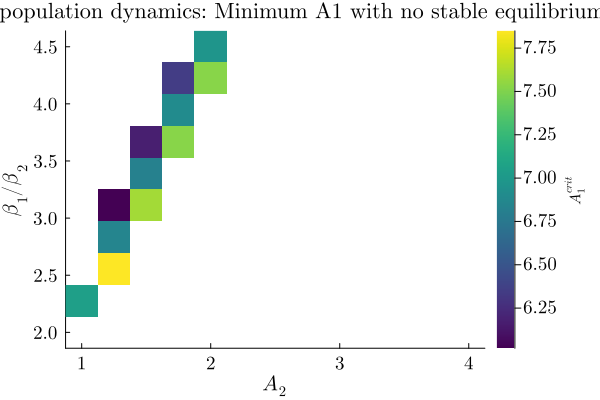

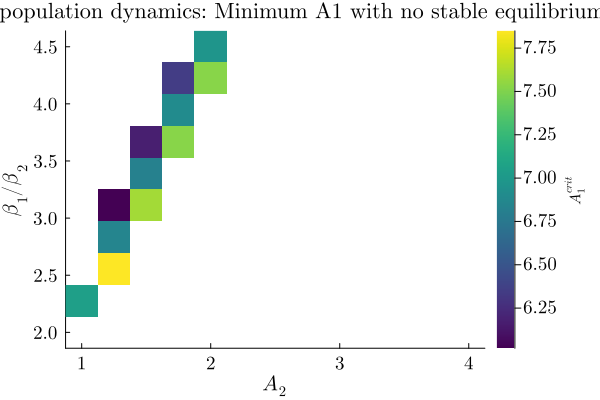

In [29]:
using ForwardDiff, LinearAlgebra

# Check whether equilibrium u_eq is locally stable for the no-group system
# by computing the Jacobian via ForwardDiff and checking that all
# eigenvalues have negative real parts.
function is_stable_nog(u_eq, p_scaled)
    J = ForwardDiff.jacobian(u -> system_nogroups(u, p_scaled, 1), u_eq)
    return all(real.(eigvals(J)) .< 0)
end

# Check whether an equilibrium is physically valid:
# all components non-negative, prey densities at most ~1.
function is_physical(u_eq)
    return all(u_eq .>= -1e-8) && all(u_eq[1:2] .<= 1.0 + 1e-8)
end

# For a given scaled parameter set, sweep over A1 values and find the largest
# A1 at which at least one of the three equilibria (coexistence, N1-extinct,
# N2-extinct) is locally stable.
# Equilibria are computed analytically via equilibrium_nogroups, etc.
# Stability is assessed via ForwardDiff Jacobian + eigenvalue check.
function stable_A1_cutoff_nog(p_nt; A1_min=0.5, A1_max=4.0, n_A1=200)
    A1_vec = range(A1_min, A1_max, length=n_A1)
    max_stable_A1 = -Inf

    for A1_val in A1_vec
        # Update A1 in the parameter set (other scaled params stay fixed)
        p_mod = merge(p_nt, (A1 = A1_val,))
        p_mod = scale_parameters(p_mod)

        # Compute the three analytical equilibria
        eqs = [
            equilibrium_nogroups(p_mod),
            equilibrium_nogroups_N1extinct(p_mod),
            equilibrium_nogroups_N2extinct(p_mod)
        ]

        for u_eq in eqs
            if is_physical(u_eq) && is_stable_nog(u_eq, p_mod)
                max_stable_A1 = A1_val
                break  # found a stable eq for this A1, no need to check others
            end
        end
    end

    return max_stable_A1
end

# Scan over A2 and beta1/beta2 (scale), and for each pair sweep A1
# to estimate A1^crit: the smallest A1 for which no stable equilibrium remains.
# Uses analytical equilibria + ForwardDiff Jacobian instead of numerical continuation.
function minimum_A1_without_stable_equilibrium_nog(
    params_base;
    A2_vec = collect(0.5:0.5:2.5),
    scale_vec = collect(range(2.0, 5.0, length = 3)),
    A1_min = 0.5,
    A1_max = 3.0,
    n_A1 = 200
)
    A1_threshold_mat_nog = fill(NaN, length(scale_vec), length(A2_vec))

    for (i, scale_val) in enumerate(scale_vec)
        for (j, A2_val) in enumerate(A2_vec)
            # Start from base parameters and overwrite for this heatmap point
            params = deepcopy(params_base)
            params[:H1a] = 0.0
            params[:H2a] = 0.0
            params[:H2b] = 1.0
            params[:scale] = scale_val
            params[:A2] = A2_val
            params[:A1] = A1_min

            p_nt = NamedTuple(scale_parameters(params))

            # Sweep A1 and find the last stable A1 value
            stable_limit = stable_A1_cutoff_nog(
                p_nt; A1_min = A1_min, A1_max = A1_max, n_A1 = n_A1
            )

            # If no stable points at all, threshold is at A1_min
            if stable_limit == -Inf
                A1_threshold_mat_nog[i, j] = A1_min
            # Record the last stable A1, if loss of stability occurs before upper bound
            elseif stable_limit < A1_max - 1e-3
                A1_threshold_mat_nog[i, j] = stable_limit
            # Otherwise stability persists through the whole range (leave as NaN)
            else
                @show scale_val
                @show A2_val
                @show stable_limit
            end
        end
    end

    return A1_threshold_mat_nog
end

# Define the heatmap grid
A2_vec_nog = collect(1.0:0.25:4.0)
scale_vec_nog = collect(range(2.0, 4.5, length = 10))
A1_min_nog = 0.5
A1_max_nog = 8.0

# Compute the threshold matrix for the no-group system
A1_threshold_mat_nog = minimum_A1_without_stable_equilibrium_nog(
    params_base_nog;
    A2_vec = A2_vec_nog,
    scale_vec = scale_vec_nog,
    A1_min = A1_min_nog,
    A1_max = A1_max_nog,
    n_A1 = 300
)

# Plot the threshold as a heatmap:
# x-axis = A2, y-axis = beta1/beta2, color = A1^crit
plt_A1_threshold_nog = heatmap(
    A2_vec_nog,
    scale_vec_nog,
    A1_threshold_mat_nog,
    xlabel = L"A_2",
    ylabel = L"\beta_1 / \beta_2",
    title = "Only population dynamics: Minimum A1 with no stable equilibrium",
    color = :viridis,
    right_margin = 8mm,
    colorbar_title = "\n" * L"A_1^{crit}"
)

display(plt_A1_threshold_nog)
plt_A1_threshold_nog

Below: for a couple choices of scale, A2, and one A1 = 1.0 and A1 = 8.0, plot the equilibria using the equilibria functions, using red star markers if unstable and black filled markers if stable.

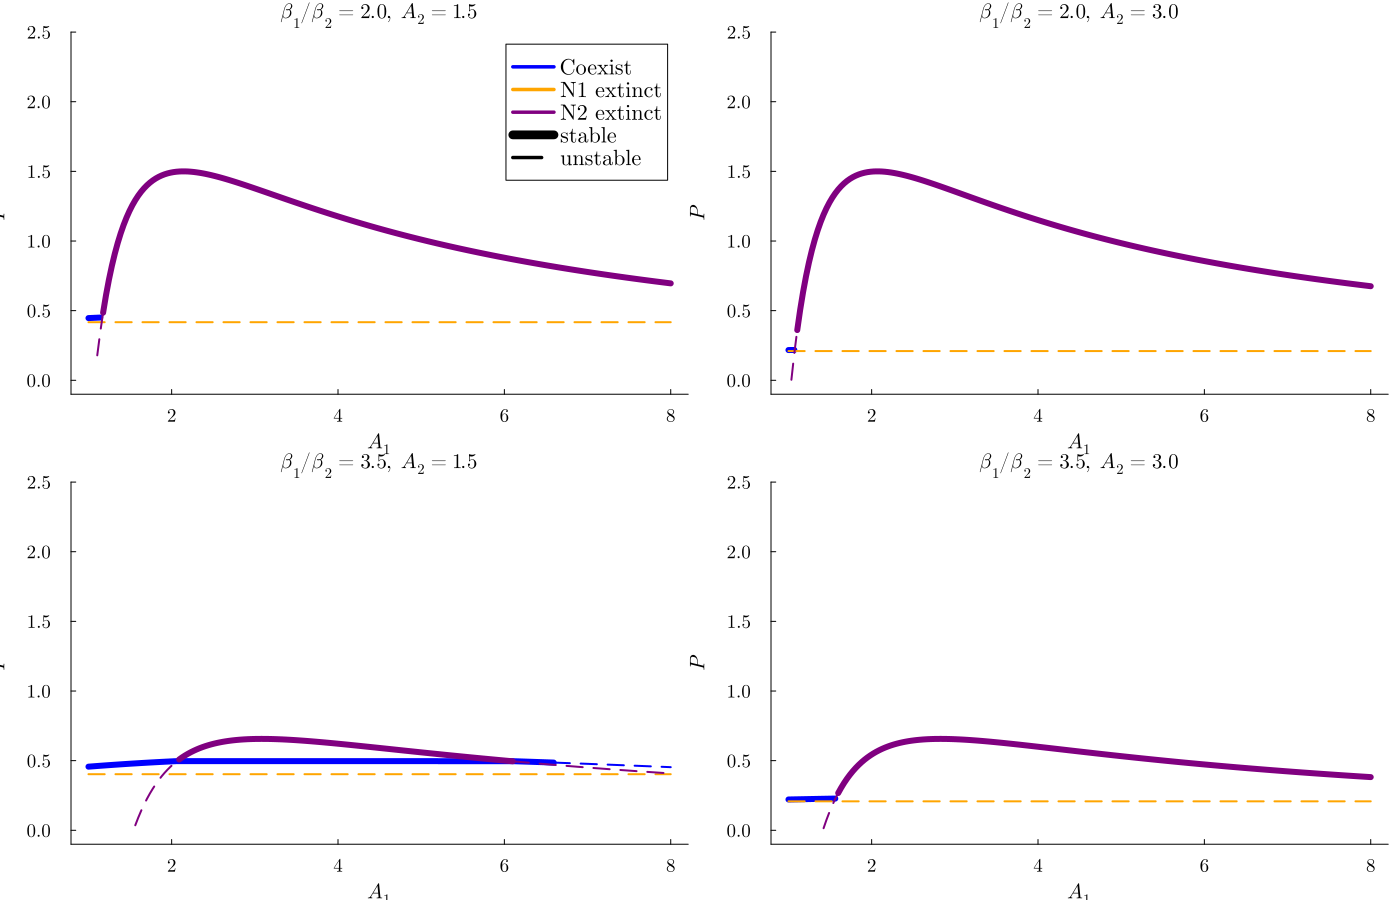

In [34]:
# For a few (scale, A2) combinations, plot equilibrium predator density P
# versus A1 (attack rate on big prey).
# Solid thick line = stable equilibrium, dashed line = unstable.

function plot_P_vs_A1(params_base_nog;
    test_cases = [
        (scale = 2.0, A2 = 1.5),
        (scale = 2.0, A2 = 3.0),
        (scale = 3.5, A2 = 1.5),
        (scale = 3.5, A2 = 3.0),
    ],
    A1_range = (1.0, 8.0),
    n_A1 = 200,
    ylims_val = (-0.1, 2.5)
)
    # A1 values to sweep over (x-axis of each subplot)
    A1_vec_test = range(A1_range..., length = n_A1)

    # Each tuple: (display name, equilibrium function, line color)
    eq_funs = [
        ("Coexist",    equilibrium_nogroups,          :blue),
        ("N1 extinct", equilibrium_nogroups_N1extinct, :orange),
        ("N2 extinct", equilibrium_nogroups_N2extinct, :purple),
    ]

    plts = []
    for (ti, tc) in enumerate(test_cases)
        # Initialize subplot for this (scale, A2) combination
        plt = plot(
            title = L"\beta_1/\beta_2=%$(tc.scale),\; A_2=%$(tc.A2)",
            xlabel = L"A_1", ylabel = L"P",
            legend = :outertopright, ylims = ylims_val
        )

        for (eq_name, eq_fun, clr) in eq_funs
            # clr = color used to distinguish the three equilibrium branches

            # For this equilibrium type, collect predator density and stability
            # at each A1 value where the equilibrium is physically valid
            P_vals = Float64[]       # predator equilibrium density
            stab_flags = Bool[]      # true if locally stable (all eigenvalues have Re < 0)
            A1_phys = Float64[]      # A1 values where the equilibrium is physical

            for A1_val in A1_vec_test
                # Build scaled parameter set for this A1
                params = deepcopy(params_base_nog)
                params[:scale] = tc.scale
                params[:A2] = tc.A2
                params[:A1] = A1_val
                p_sc = NamedTuple(scale_parameters(params))

                # Compute the analytical equilibrium
                u_eq = eq_fun(p_sc)
                phys = is_physical(u_eq)
                if !phys
                    continue  # skip non-physical equilibria (negative densities, N>1, etc.)
                end
                push!(A1_phys, A1_val)
                push!(P_vals, u_eq[3])  # u_eq = [N1, N2, P]; take P
                push!(stab_flags, is_stable_nog(u_eq, p_sc))
            end

            isempty(A1_phys) && continue

            # Draw segments: solid thick = stable, dashed = unstable
            # clr distinguishes the equilibrium branch (blue/orange/purple)
            plot_segments!(A1_phys, P_vals, stab_flags;
                color = clr, plot_legend = false)
            # Invisible line to add a colored legend entry for this branch
            plot!([], []; color = clr, label = eq_name, linewidth = 2)
        end

        # Re-enable legend (plot_segments! disables it with legend=false)
        if ti == 1
            plot!(legend = :topright)
        end

        # Add stable/unstable line-style legend entries on the first subplot only
        if ti == 1
            plot!([], []; linestyle = :solid, color = :black, linewidth = 6, label = "stable")
            plot!([], []; linestyle = :dash, color = :black, linewidth = 2, label = "unstable")
        end

        push!(plts, plt)
    end

    return plot(plts..., layout = (length(test_cases) ÷ 2, 2), size = (1400, 900))
end

plot_P_vs_A1(params_base_nog)

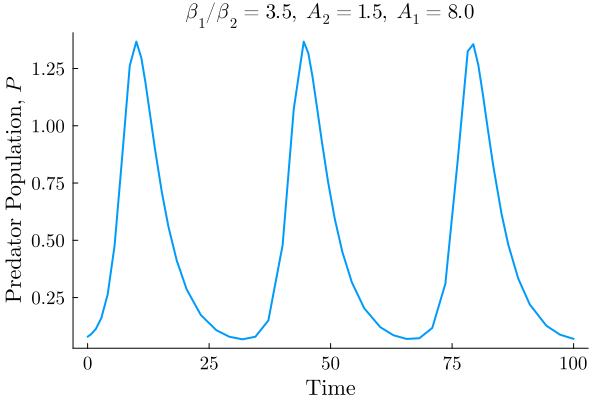

In [35]:
# Example of instability: β1/β2 = 3.5, A2 = 1.5, A1 = 8.0
# Simulate the no-group system to show cycling/unstable dynamics.

params = deepcopy(params_base_nog)
params[:scale] = 3.5
params[:A2] = 1.5
params[:A1] = 8.0
p_nt = NamedTuple(scale_parameters(params))

u0 = [0.5, 0.4, 0.5]

# Burn-in: 1000 time units
tspan_burn = (0.0, 1000.0)
prob_burn = ODEProblem(system_scaled_nogroups!, u0, tspan_burn, p_nt)
sol_burn = solve(prob_burn)
u_f = sol_burn[:, end]

# Plot: 100 more time units
tspan_plot = (0.0, 100.0)
prob_plot = ODEProblem(system_scaled_nogroups!, u_f, tspan_plot, p_nt)
sol_plot = solve(prob_plot)

P_plot = [u[3] for u in sol_plot.u]
plot(sol_plot.t, P_plot;
    xlabel = "Time", ylabel = L"Predator Population, $P$",
    title = L"\beta_1/\beta_2=3.5,\; A_2=1.5,\; A_1=8.0",
    legend = false, linewidth = 2)


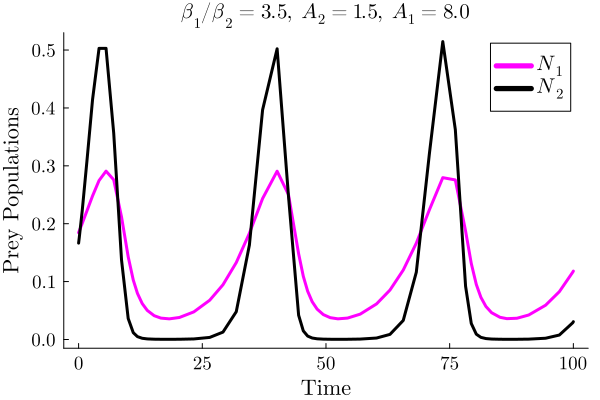

In [36]:
N1_plot = [u[1] for u in sol_plot.u]
N2_plot = [u[2] for u in sol_plot.u]
plot(sol_plot.t, N1_plot; label = L"N_1", linewidth = 3, color = :magenta)
plot!(sol_plot.t, N2_plot; label = L"N_2", linewidth = 3, color = :black)
plot!(xlabel = "Time", ylabel = "Prey Populations",
    title = L"\beta_1/\beta_2=3.5,\; A_2=1.5,\; A_1=8.0",
    legend = :topright)


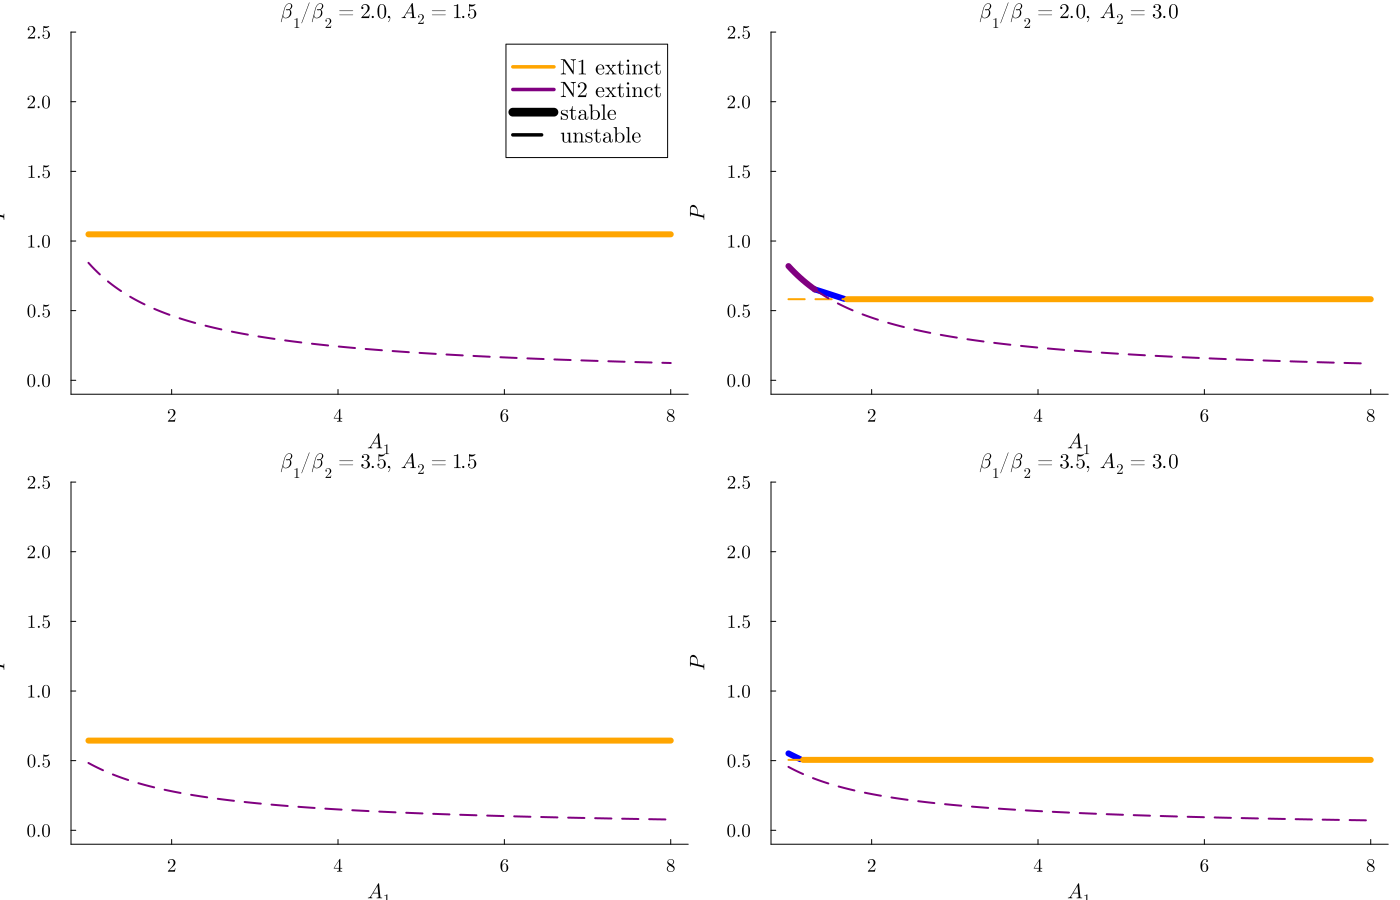

In [41]:
params_base_nog4 = deepcopy(params_base_nog)
params_base_nog4[:x] = 3.0
plot_P_vs_A1(params_base_nog4)